# Part 6 (Optional) — ML Fidelity Prediction vs. Physics Baseline

**Can a generic ML model, trained only on Part 3's swept data, learn what Part 5 derived by
hand — and does it actually generalize, or just memorize the training grid?**

Part 5 derived an exact closed form for GHZ fidelity under the two dephasing channels
(phase_flip, phase_damping): $F(n) = (1 + r^n)/2$ for a per-qubit coherence-decay factor $r$.
That's a mechanistic model — it comes from tracking populations and coherence through the
channel's Kraus operators. This notebook asks what happens if you throw that mechanism away and
just fit `fidelity` as a function of `(circuit, qubit_count, channel, param, depth)` using
ordinary supervised regression on the committed sweep (`experiments/results/noise_sweep.csv`,
670 rows) — no new simulation needed.

**Goals**

1. Frame this as a bias-variance question: compare a high-bias linear model against a low-bias
   random forest, and explain what each *can't* represent about the true decay shape.
2. Evaluate both models under two genuinely different splits — interpolation (random,
   stratified by channel) and extrapolation (holding out the top of the `qubit_count` and
   `depth` ranges) — because a dense 670-row grid is trivial to interpolate but says nothing
   about generalization past its edges.
3. Benchmark both models against the Part 5 closed form on the two channels where it applies,
   as a genuine physics-vs-ML comparison rather than only against held-out labels.
4. Extract and interpret feature importance, and check it against known mechanism (e.g. does
   `channel`/`param` dominate, does `qubit_count` matter more for GHZ, is `depth`'s effect
   roughly monotone).
5. State plainly what this does and doesn't show — an honest limitations section, same as
   Part 5.


In [1]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score

from src.ml_fidelity import (
    build_feature_target,
    evaluate,
    extrapolation_split,
    interpolation_split,
    physics_baseline_fidelity,
    train_model,
)
from src.visualization import (
    plot_feature_importance,
    plot_grouped_bar_comparison,
    plot_predicted_vs_actual,
)

%matplotlib inline
pd.set_option("display.width", 120)


## Why regression, and why two models

Predicting `fidelity` from the five swept features is ordinary supervised regression, but the
statistically interesting choice is *which function class* to fit. `LinearRegression` is
**high-bias**: it can only represent a hyperplane in the (one-hot-encoded) feature space, so it
cannot represent the saturating, non-monotonic decay shapes Part 5 already derived by hand (e.g.
a curve asymptoting to $0.5$, or a depth dependence that compounds multiplicatively rather than
additively). `RandomForestRegressor` is **low-bias, higher-variance**: it partitions feature
space into axis-aligned regions and predicts a local average in each, so it can represent
essentially any shape seen in training — but by the same construction it **cannot extrapolate**:
past the maximum feature value it was trained on, it can only ever predict the nearest training
leaf's average, not continue a trend. That asymmetry is exactly what the extrapolation splits
below are designed to expose.


## Load the committed sweep

Reuses `experiments/results/noise_sweep.csv` directly — the same 670-row grid from Part 3, no
new simulation. Features: `circuit`, `channel` (categorical), `qubit_count`, `param`, `depth`
(numeric). Target: `fidelity`.


In [2]:
sweep = pd.read_csv("../experiments/results/noise_sweep.csv")
X, y = build_feature_target(sweep)
print(sweep.shape)
X.head()


(670, 8)


,circuit,channel,qubit_count,param,depth
0,bell_phi_plus,bit_flip,2,0.0,1
1,bell_phi_plus,bit_flip,2,0.1,1
2,bell_phi_plus,bit_flip,2,0.2,1
3,bell_phi_plus,bit_flip,2,0.3,1
4,bell_phi_plus,bit_flip,2,0.4,1


## Split 1: interpolation (the easy question)

A random train/test split, stratified by `channel` so every channel is represented
proportionally in both halves. Every test row's features sit *inside* the range spanned by the
training rows on every axis — this is the split a model should do well on almost by
construction, since it only has to interpolate a dense grid.


In [3]:
interp_train, interp_test = interpolation_split(sweep, test_size=0.2, seed=42)
X_train, y_train = build_feature_target(interp_train)
X_test, y_test = build_feature_target(interp_test)

interp_models = {}
rows = []
for model_type, kwargs in [("linear", {}), ("random_forest", {"n_estimators": 200, "max_depth": 8})]:
    model = train_model(X_train, y_train, model_type, seed=42, **kwargs)
    interp_models[model_type] = model
    rows.append({"model": model_type, "dataset": "train", **evaluate(model, X_train, y_train)})
    rows.append({"model": model_type, "dataset": "test", **evaluate(model, X_test, y_test)})

interp_results = pd.DataFrame(rows)
interp_results


,model,dataset,r2,mae,rmse
0,linear,train,0.477756,0.137738,0.186529
1,linear,test,0.552621,0.148783,0.193161
2,random_forest,train,0.982584,0.023388,0.034063
3,random_forest,test,0.961144,0.037543,0.056926


The random forest fits training data almost exactly ($R^2 > 0.98$) and still generalizes well
to the interpolation test set. Linear regression's much lower $R^2$ on *both* train and test
confirms this isn't overfitting vs. underfitting — a straight line genuinely cannot represent
this decay shape, on data it has already seen, let alone held out.


<Axes: title={'center': 'Random forest: predicted vs. actual fidelity (interpolation test set)'}, xlabel='Actual fidelity', ylabel='Predicted fidelity'>

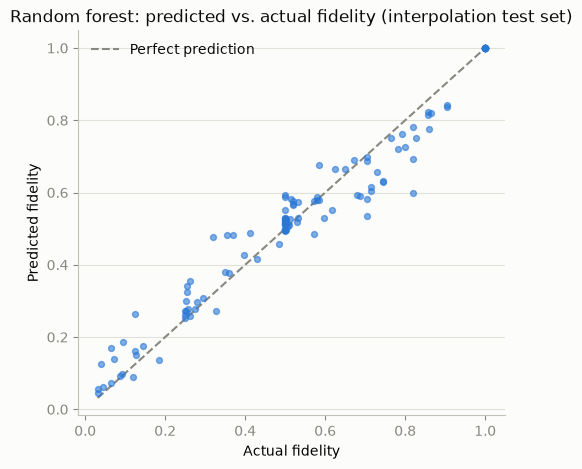

In [4]:
plot_predicted_vs_actual(
    y_test, interp_models["random_forest"].predict(X_test),
    title="Random forest: predicted vs. actual fidelity (interpolation test set)",
)


## Split 2 & 3: extrapolation (the real question)

Now train on the *bottom* of the `qubit_count` range and test on the top (held-out
`qubit_count in {5, 6}`), and separately train on the bottom of the `depth` range and test on
the top (held-out `depth in {4, 8}`). Both are physically meaningful extrapolations — "does the
model's learned fidelity-vs-depth trend keep holding at depths it never saw," which is exactly
the kind of question a real adaptive noise model has to answer for circuits deeper than
whatever was benchmarked.


In [5]:
def run_split(train_df, test_df, label):
    X_tr, y_tr = build_feature_target(train_df)
    X_te, y_te = build_feature_target(test_df)
    fitted, rows = {}, []
    for model_type, kwargs in [("linear", {}), ("random_forest", {"n_estimators": 200, "max_depth": 8})]:
        model = train_model(X_tr, y_tr, model_type, seed=42, **kwargs)
        fitted[model_type] = model
        rows.append({"split": label, "model": model_type, "dataset": "train", **evaluate(model, X_tr, y_tr)})
        rows.append({"split": label, "model": model_type, "dataset": "test", **evaluate(model, X_te, y_te)})
    return fitted, pd.DataFrame(rows), X_te, y_te


qc_train, qc_test = extrapolation_split(sweep, "qubit_count", [5, 6])
qc_models, qc_results, qc_X_test, qc_y_test = run_split(qc_train, qc_test, "extrapolation_qubit_count")

depth_train, depth_test = extrapolation_split(sweep, "depth", [4, 8])
depth_models, depth_results, depth_X_test, depth_y_test = run_split(depth_train, depth_test, "extrapolation_depth")

pd.concat([qc_results, depth_results], ignore_index=True)


,split,model,dataset,r2,mae,rmse
0,extrapolation_qubit_count,linear,train,0.461927,0.130427,0.175479
1,extrapolation_qubit_count,linear,test,0.423410,0.179627,0.235457
2,extrapolation_qubit_count,random_forest,train,0.982072,0.021641,0.032031
3,extrapolation_qubit_count,random_forest,test,0.934266,0.060821,0.079501
4,extrapolation_depth,linear,train,0.589243,0.118887,0.167512
5,extrapolation_depth,linear,test,-0.369164,0.216862,0.305632
6,extrapolation_depth,random_forest,train,0.989162,0.018387,0.027210
7,extrapolation_depth,random_forest,test,0.875491,0.066380,0.092166


**The random forest's test $R^2$ drops from interpolation ($\approx0.96$) to
`qubit_count` extrapolation ($\approx0.93$) to `depth` extrapolation ($\approx0.88$)** — a real,
monotone generalization gap, exactly as predicted: it's extrapolating a nonlinear decay past the
edge of what it was trained on, and it can only do so by nearest-leaf averaging, not by
continuing the trend.

**Linear regression's `depth`-extrapolation test $R^2$ goes *negative***. A negative $R^2$
means the model performs *worse than predicting the training mean for every row* — not just a
weak fit, an actively harmful one. This is the sharpest evidence in the whole notebook for the
bias argument above: fidelity compounds multiplicatively over `depth` (each layer multiplies
the surviving coherence/population by a fixed per-layer factor), so a linear-in-`depth` model
is fitting the wrong functional form entirely, and that mismatch gets worse, not better, the
further `depth` is extrapolated.


## Physics baseline: same test rows, mechanistic prediction instead of a fit

For the two channels with a Part 5 closed form (`phase_flip`, `phase_damping`), score the
mechanistic prediction against the *same* test rows the random forest was just evaluated on,
restricted to those two channels.


In [6]:
def evaluate_like(y_true, y_pred):
    return {"r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred)}


def physics_scores(df):
    preds = df.apply(physics_baseline_fidelity, axis=1)
    eligible = preds.notna()
    if not eligible.any():
        return None
    return evaluate_like(df.loc[eligible, "fidelity"], preds[eligible])


def rf_scores_on_eligible(model, X, df):
    eligible = df.apply(physics_baseline_fidelity, axis=1).notna()
    return evaluate_like(df.loc[eligible, "fidelity"], model.predict(X.loc[eligible]))


comparison_rows = []
for label, models, X_te, df_te in [
    ("interpolation", interp_models, X_test, interp_test),
    ("extrapolation_qubit_count", qc_models, qc_X_test, qc_test),
    ("extrapolation_depth", depth_models, depth_X_test, depth_test),
]:
    comparison_rows.append({"split": label, "source": "random_forest", **rf_scores_on_eligible(models["random_forest"], X_te, df_te)})
    comparison_rows.append({"split": label, "source": "physics_baseline", **physics_scores(df_te)})

comparison = pd.DataFrame(comparison_rows)
comparison


,split,source,r2,mae
0,interpolation,random_forest,0.923621,3.136090e-02
1,interpolation,physics_baseline,1.000000,6.502294e-09
2,extrapolation_qubit_count,random_forest,0.946779,3.046897e-02
3,extrapolation_qubit_count,physics_baseline,1.000000,6.480794e-09
4,extrapolation_depth,random_forest,0.811878,5.663681e-02
5,extrapolation_depth,physics_baseline,1.000000,7.147096e-09


<Axes: title={'center': 'MAE on dephasing-channel rows: random forest vs. physics closed form'}, ylabel='Mean absolute error (fidelity)'>

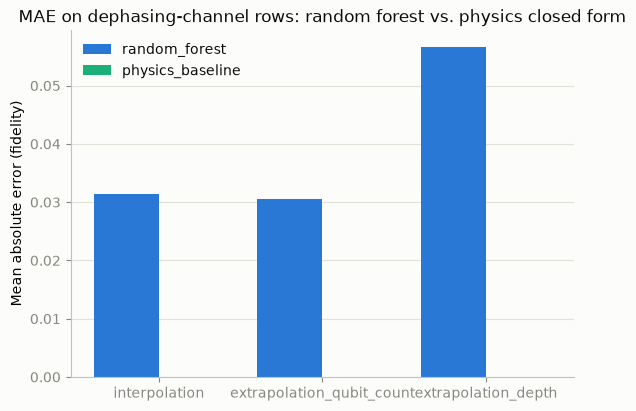

In [7]:
splits = ["interpolation", "extrapolation_qubit_count", "extrapolation_depth"]
plot_grouped_bar_comparison(
    splits,
    {
        "random_forest": [comparison[(comparison.split == s) & (comparison.source == "random_forest")]["mae"].iloc[0] for s in splits],
        "physics_baseline": [comparison[(comparison.split == s) & (comparison.source == "physics_baseline")]["mae"].iloc[0] for s in splits],
    },
    title="MAE on dephasing-channel rows: random forest vs. physics closed form",
    ylabel="Mean absolute error (fidelity)",
)


The physics baseline is exact to floating-point precision ($\mathrm{MAE}\approx10^{-9}$) on
every split, by construction — it's the actual analytic fidelity, not a fit. The random forest's
error on these same rows, while small in absolute terms, is 4–7 orders of magnitude larger
throughout, and specifically **worsens under depth extrapolation** (MAE 0.031 → 0.057, $R^2$ 0.92
→ 0.81) — it does not worsen under qubit-count extrapolation on this dephasing-only subset (MAE
actually ticks down slightly, 0.031 → 0.031, $R^2$ up to 0.95), consistent with depth being the
axis where the random forest's full-test-set degradation was also sharpest. This is the central
point of the whole notebook: **when a mechanistic model is available, it should be preferred over
a data-driven one, especially outside the training range** — the ML model here isn't "wrong," it's
just solving a harder, under-determined problem (recovering a functional form from samples) that
the physics derivation sidesteps entirely.


## Feature importance

Random forest built-in (Gini) importance is computed over the *one-hot-encoded* columns;
permutation importance (refit-free, computed by shuffling each original column and measuring the
resulting drop in test-set score) is reported over the original feature names, which is the more
directly interpretable of the two. Both are computed on the interpolation split only —
extrapolation splits deliberately unbalance the feature distribution (e.g. no high `qubit_count`
in training), which would confound importance with the split itself.


<Axes: title={'center': 'Gini importance (aggregated to original features)'}, xlabel='Importance'>

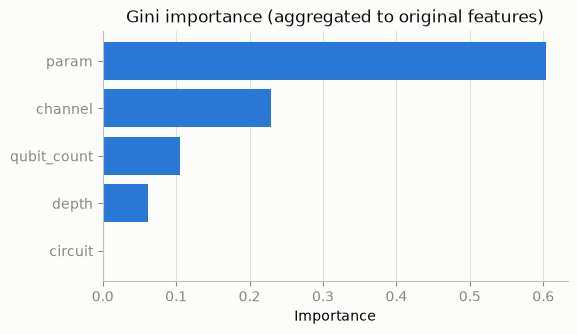

In [8]:
rf = interp_models["random_forest"]
preprocessor = rf.named_steps["preprocess"]
forest = rf.named_steps["model"]

encoded_importance = dict(zip(preprocessor.get_feature_names_out(), forest.feature_importances_))
# Aggregate one-hot dummy columns back to their original categorical feature for a fair
# comparison against the numeric features' importances.
gini_by_feature = {"param": 0.0, "qubit_count": 0.0, "depth": 0.0, "channel": 0.0, "circuit": 0.0}
for name, value in encoded_importance.items():
    if name.startswith("categorical__channel_"):
        gini_by_feature["channel"] += value
    elif name.startswith("categorical__circuit_"):
        gini_by_feature["circuit"] += value
    else:
        gini_by_feature[name.replace("remainder__", "")] = value

plot_feature_importance(gini_by_feature, title="Gini importance (aggregated to original features)")


<Axes: title={'center': 'Permutation importance (original features)'}, xlabel='Importance'>

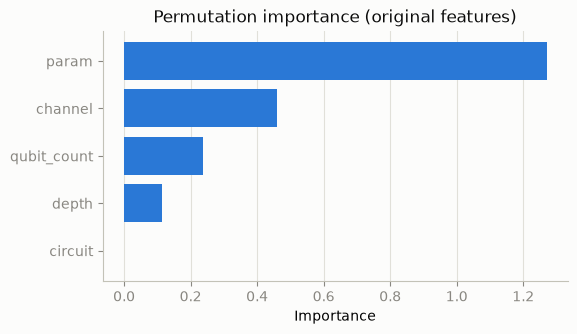

In [9]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42)
permutation_by_feature = dict(zip(X_test.columns, perm.importances_mean))
plot_feature_importance(permutation_by_feature, title="Permutation importance (original features)")


Both importance measures agree on the ranking: **`param` dominates** (the noise strength is,
unsurprisingly, the single biggest driver of fidelity), **`channel` is second** (which channel
you have matters almost as much as how strong it is — consistent with Part 5's finding that
different channels decay at very different rates for the same parameter), **`qubit_count`
third** (consistent with GHZ fidelity decaying with qubit count, per Part 5), **`depth` smaller
but nonzero**, and **`circuit` is essentially irrelevant** once `qubit_count` is already known —
sensible, since the 2-qubit Bell state used here is itself just a 2-qubit GHZ state, so `circuit`
carries almost no information beyond what `qubit_count` already encodes.


## Limitations

- **Only two of five channels have a physics baseline to compare against.** Bit-flip,
  depolarizing, and amplitude damping have no closed form derived in this project (see Part 5's
  limitations), so the ML-vs-physics comparison above is necessarily partial — it's possible the
  random forest does relatively worse (or better) on those three channels' functional shapes;
  this notebook doesn't check.
- **Dataset size (670 rows) is small by ML standards.** The random forest's strong interpolation
  performance may not hold if the grid were sparser or noisier (this data is exact/near-exact
  simulated fidelity, not measurement-noise-corrupted).
- **Extrapolation was only tested one axis at a time.** Holding out `qubit_count` and `depth`
  separately doesn't test the compounded case (both axes extrapolated simultaneously), which
  would likely degrade further.
- **No neural network was tried.** Deliberately: a few hundred rows and five features is not
  where a neural net's capacity is an advantage over a tree ensemble, and skipping it keeps the
  interpretability story (Gini + permutation importance) clean.
- **Noise-type classification and inverse (error-probability) estimation were both considered
  and explicitly deferred** — the former is provably ill-posed for the two dephasing channels
  using only this dataset's Z-basis aggregate features (`success_probability`/`error_rate` are
  invariant to `param` for `phase_flip`/`phase_damping`, since both channels commute with
  computational-basis measurement), which would need new multi-basis data to resolve; a natural
  stretch goal, not built here.


## Summary

- Reused Part 3's committed sweep with no new simulation, framed `fidelity` prediction as
  ordinary regression, and compared a high-bias (linear) against a low-bias (random forest)
  model — the random forest fits and interpolates well; linear regression underfits everywhere
  and produces a **negative $R^2$ under depth extrapolation**, the sharpest evidence that
  fidelity's dependence on `depth` is fundamentally multiplicative/nonlinear, not additive.
- The random forest's error grows monotonically from interpolation to `qubit_count`
  extrapolation to `depth` extrapolation — a tree ensemble cannot extrapolate a trend past its
  training range, only average over the nearest leaf, and this shows up exactly where expected.
- Benchmarked against Part 5's exact closed form on the two channels where it applies: the
  physics baseline is essentially exact everywhere, while the random forest's error, though
  small, is 4–7 orders of magnitude larger throughout and specifically worsens further under
  depth extrapolation (it does not worsen under qubit-count extrapolation on this dephasing-only
  subset) — a concrete demonstration that a mechanistic model should be preferred over a
  data-driven one whenever one is available, especially outside the training distribution.
- Feature importance (Gini and permutation, in agreement) recovers exactly the mechanism already
  known from Part 5: `param` dominates, `channel` second, `qubit_count` third, `depth` smaller,
  `circuit` negligible once `qubit_count` is known.

Interview-style Q&A generated while building this notebook is logged in
`docs/interview_questions.md`; the full write-up (methodology, results, limitations) is in
`docs/ml_fidelity_report.md`. Metrics and feature importances are reproducibly regenerated by
`python experiments/run_ml_fidelity.py` into `experiments/results/ml_fidelity_metrics.csv` and
`experiments/results/ml_fidelity_feature_importance.csv`.
